In [1]:
pip install scanpy anndata pandas scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install openpyxl

In [3]:
file_path_FSHS1_1 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487556_FSHD1.1.txt"
file_path_FSHS1_2 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487557_FSHD1.2.txt"
file_path_FSHS2_1 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487558_FSHD2.1.txt"
file_path_FSHS2_2 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487559_FSHD2.2.txt"
file_path_ctr1 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487560_CTRL.1.txt"
file_path_ctr2 = r"C:\Users\Tanya\Desktop\RNA sequencing\GSM3487561_CTRL.2.txt"

In [4]:
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

# load matrix
file_path = file_path_FSHS1_1
counts_gene_by_cell = pd.read_csv(
    file_path,
    sep="\t",
    index_col=0
)


counts_gene_by_cell.index = counts_gene_by_cell.index.astype(str).str.replace('"', '', regex=False)
counts_gene_by_cell.columns = counts_gene_by_cell.columns.astype(str).str.replace('"', '', regex=False)

# 3. 转置成 Scanpy/AnnData 需要的格式：cells × genes
counts_cell_by_gene = counts_gene_by_cell.T

# 4. 建立 AnnData object
adata = ad.AnnData(
    X=sparse.csr_matrix(counts_cell_by_gene.values),
    obs=pd.DataFrame(index=counts_cell_by_gene.index),
    var=pd.DataFrame(index=counts_cell_by_gene.columns)
)

# 5. 加上 sample 信息
adata.obs["sample"] = "FSHD1.1"

# 6. 保存原始 counts
adata.layers["counts"] = adata.X.copy()

# 7. 确保基因名唯一
adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 2245 × 33694
    obs: 'sample'
    layers: 'counts'


In [5]:
import numpy as np

In [6]:
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

def read_count_matrix(file_path, sample_name):
    counts = pd.read_csv(file_path, sep="\t", index_col=0)

    counts.index = counts.index.astype(str).str.replace('"', '', regex=False)
    counts.columns = counts.columns.astype(str).str.replace('"', '', regex=False)

    counts = counts.T  # cells × genes

    adata = ad.AnnData(
        X=sparse.csr_matrix(counts.values),
        obs=pd.DataFrame(index=counts.index),
        var=pd.DataFrame(index=counts.columns)
    )

    adata.obs["sample"] = sample_name
    adata.layers["counts"] = adata.X.copy()
    adata.var_names_make_unique()

    return adata


adata1 = read_count_matrix(file_path_FSHS1_1, "FSHD1.1")
adata2 = read_count_matrix(file_path_FSHS1_2, "FSHD1.2")
adata3 = read_count_matrix(file_path_FSHS2_1, "FSHD2.1")
adata4 = read_count_matrix(file_path_FSHS2_2, "FSHD2.2")
adata5 = read_count_matrix(file_path_ctr1, "CTR1")
adata6 = read_count_matrix(file_path_ctr2, "CTR2")

# 合并多个样本
adata = ad.concat(
    [adata1, adata2, adata3, adata4,adata5, adata6],
    label="sample_batch",
    keys=["FSHD1.1", "FSHD1.2","FSHD2.1","FSHD2.2","CTR1","CTR2"],
    join="outer",
    index_unique="-",
    fill_value=0
)

print(adata)
adata.write_h5ad("combined_raw_counts.h5ad")



AnnData object with n_obs × n_vars = 7047 × 33694
    obs: 'sample', 'sample_batch'
    layers: 'counts'


AnnData object with n_obs × n_vars = 7047 × 33694
    obs: 'sample', 'sample_batch'
    layers: 'counts'
                           sample sample_batch
AAACATACTATGCG-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACATTGGCGAAG-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACATTGTGAAGA-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACCGTGTGTTTC-1-FSHD1.1  FSHD1.1      FSHD1.1
AAACGCACCTGCAA-1-FSHD1.1  FSHD1.1      FSHD1.1


C:\Users\Tanya\AppData\Local\Temp\ipykernel_28936\2120443500.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby("sample_batch")[["total_counts", "n_genes_by_counts"]].describe()


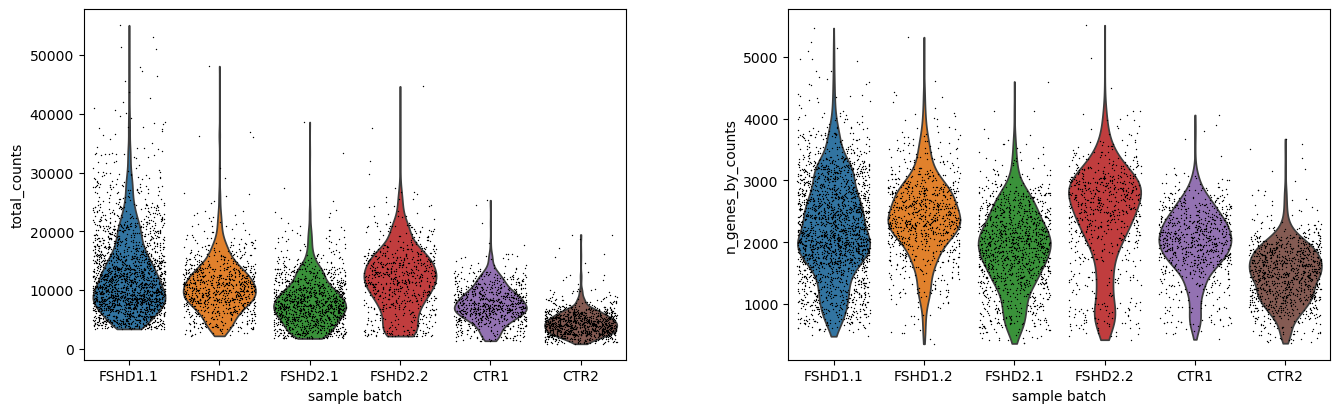

In [7]:
adata = sc.read_h5ad("combined_raw_counts.h5ad")

# 确保 cell names / gene names 唯一
adata.obs_names_make_unique()
adata.var_names_make_unique()

print(adata)
print(adata.obs.head())

sc.pp.calculate_qc_metrics(
    adata,
    inplace=True
)


adata.obs.groupby("sample_batch")[["total_counts", "n_genes_by_counts"]].describe()
sc.pl.violin(
    adata,
    ["total_counts", "n_genes_by_counts"],
    groupby="sample_batch",
    jitter=0.4,
    multi_panel=True
)

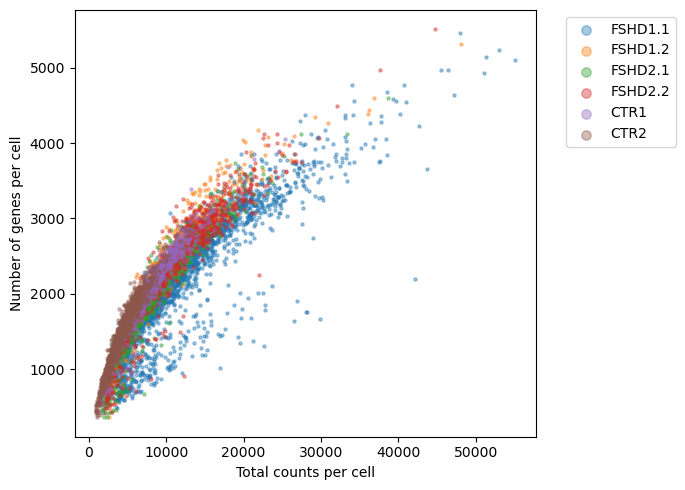

C:\Users\Tanya\AppData\Local\Temp\ipykernel_28936\569852325.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["total_counts"].corr(x["n_genes_by_counts"], method="spearman"))


sample_batch
FSHD1.1    0.904163
FSHD1.2    0.959738
FSHD2.1    0.967815
FSHD2.2    0.947967
CTR1       0.973387
CTR2       0.970566
dtype: float64

In [8]:
import matplotlib.pyplot as plt

samples = adata.obs["sample_batch"].unique()
# correlation between number of genes and total counts
plt.figure(figsize=(7, 5))

for sample in samples:
    sub = adata.obs[adata.obs["sample_batch"] == sample]
    plt.scatter(
        sub["total_counts"],
        sub["n_genes_by_counts"],
        s=5,
        alpha=0.4,
        label=sample
    )

plt.xlabel("Total counts per cell")
plt.ylabel("Number of genes per cell")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

corr_by_sample = (
    adata.obs
    .groupby("sample_batch", observed=True)
    .apply(lambda x: x["total_counts"].corr(x["n_genes_by_counts"], method="spearman"))
)

corr_by_sample

In [9]:

# Summarize QC metrics by sample
qc_summary = (
    adata.obs
    .groupby("sample_batch", observed=True)[["total_counts", "n_genes_by_counts"]]
    .quantile([0.01, 0.05, 0.50, 0.95, 0.99])
)

qc_summary

total_counts  n_genes_by_counts
sample_batch                                      
FSHD1.1      0.01       3630.68             679.16
             0.05       4479.60             918.40
             0.50      11297.00            2175.00
             0.95      26536.60            3539.40
             0.99      37297.92            4274.20
FSHD1.2      0.01       2705.93             802.41
             0.05       4023.05            1246.20
             0.50      10208.50            2399.00
             0.95      18128.75            3470.05
             0.99      25304.10            4047.16
FSHD2.1      0.01       1876.44             543.61
             0.05       2541.45             759.70
             0.50       7557.00            1932.50
             0.95      15082.50            2890.95
             0.99      20215.66            3463.13
FSHD2.2      0.01       2255.33             551.18
             0.05       2854.05             778.40
             0.50      11797.00            2567.50
             0.95      20935.80            3456.90
             0.99      26275.27            3998.80
CTR1         0.01       1483.84             644.44
             0.05       2673.60             937.00
             0.50       7431.00            2036.00
             0.95      12933.20            2790.00
             0.99      15871.80            3102.48
CTR2         0.01       1021.00             461.00
             0.05       1637.00             744.00
             0.50       4217.00            1504.00
             0.95       7847.00            2163.00
             0.99      11756.00            2765.00

In [10]:
# QC:

# Make a copy before filtering
adata_qc = adata.copy()

# Calculate QC metrics if not already calculated
sc.pp.calculate_qc_metrics(adata_qc, inplace=True)

# Basic lower thresholds
# Remove cells with very low RNA capture
min_genes = 700
min_counts = 2200

adata_qc = adata_qc[
    (adata_qc.obs["n_genes_by_counts"] > min_genes) &
    (adata_qc.obs["total_counts"] > min_counts),
    :
].copy()


print("Before filtering:", adata.n_obs, "cells")
print("After upper filtering:", adata_qc.n_obs, "cells")

Before filtering: 7047 cells
After upper filtering: 6771 cells


In [11]:
adata_filter = adata_qc.copy()

# Mark high-count but low-gene cells
# Calculate counts per detected gene for each cell
adata_filter.obs["counts_per_gene"] = (
    adata_filter.obs["total_counts"] / 
    adata_filter.obs["n_genes_by_counts"]
)
print(adata_filter.obs["counts_per_gene"])

# Mark cells with high counts per gene ratio
adata_filter.obs["qc_high_counts_per_gene"] = (
    adata_filter.obs["counts_per_gene"] > 8
)

# Count marked cells per sample
pd.crosstab(
    adata_filter.obs["sample_batch"],
    adata_filter.obs["qc_high_counts_per_gene"]
)

AAACATACTATGCG-1-FSHD1.1    5.272375
AAACATTGGCGAAG-1-FSHD1.1    6.215493
AAACATTGTGAAGA-1-FSHD1.1    5.063244
AAACCGTGTGTTTC-1-FSHD1.1    5.231870
AAACGCACCTGCAA-1-FSHD1.1    6.994301
                              ...   
TTTAGAGAGCGTTA-1-CTR2       2.471060
TTTAGAGATCTCTA-1-CTR2       3.628632
TTTCAGTGGCATAC-1-CTR2       2.515216
TTTCCAGAAACCGT-1-CTR2       2.558690
TTTGACTGTTGGTG-1-CTR2       3.063210
Name: counts_per_gene, Length: 6771, dtype: float64


qc_high_counts_per_gene,False,True
sample_batch,,
FSHD1.1,2049,165
FSHD1.2,876,4
FSHD2.1,1220,2
FSHD2.2,682,5
CTR1,784,0
CTR2,984,0


In [12]:
# filter: Remove cells with high counts per gene ratio
adata_qc2 = adata_filter[
    ~adata_filter.obs["qc_high_counts_per_gene"]
].copy()

print("Before filtering:", adata_filter.n_obs, "cells")
print("After filtering:", adata_qc2.n_obs, "cells")

Before filtering: 6771 cells
After filtering: 6595 cells


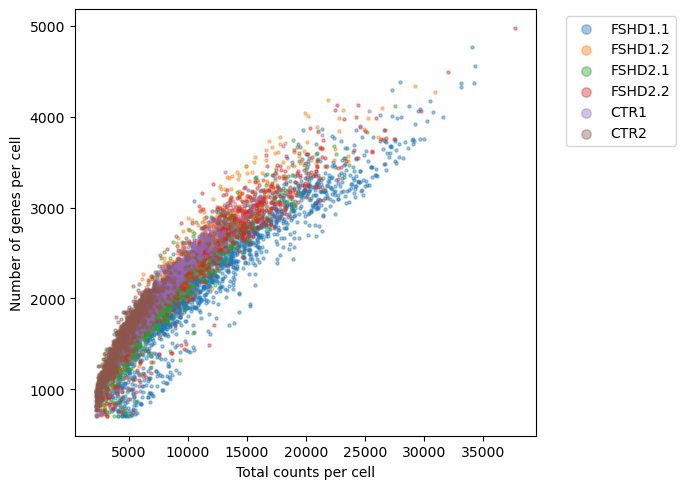

C:\Users\Tanya\AppData\Local\Temp\ipykernel_28936\4002963948.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["total_counts"].corr(x["n_genes_by_counts"], method="spearman"))


sample_batch
FSHD1.1    0.956925
FSHD1.2    0.958071
FSHD2.1    0.964478
FSHD2.2    0.947805
CTR1       0.970399
CTR2       0.959724
dtype: float64

In [13]:
# counts/genes correlation per cell after second qc
samples = adata_qc2.obs["sample_batch"].unique()
# correlation between number of genes and total counts
plt.figure(figsize=(7, 5))

for sample in samples:
    sub = adata_qc2.obs[adata_qc2.obs["sample_batch"] == sample]
    plt.scatter(
        sub["total_counts"],
        sub["n_genes_by_counts"],
        s=5,
        alpha=0.4,
        label=sample
    )

plt.xlabel("Total counts per cell")
plt.ylabel("Number of genes per cell")
plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

corr_by_sample = (
    adata_qc2.obs
    .groupby("sample_batch", observed=True)
    .apply(lambda x: x["total_counts"].corr(x["n_genes_by_counts"], method="spearman"))
)

corr_by_sample

In [14]:
# copy for normalization
adata_norm = adata_qc2.copy()

# Store raw counts before normalization
adata_norm.layers["counts"] = adata_norm.X.copy()

# Normalize each cell to the same total count
sc.pp.normalize_total(
    adata_norm,
    target_sum=1e4
)

# Log-transform the normalized data
sc.pp.log1p(adata_norm)

# Store log-normalized data
adata_norm.layers["lognorm"] = adata_norm.X.copy()

adata_norm.write_h5ad("combined_qc_normalized.h5ad")



# Calculate mean expression for each gene
X = adata_norm.X

if sparse.issparse(X):
    gene_means = np.asarray(X.mean(axis=0)).ravel()
else:
    gene_means = X.mean(axis=0)

# Get top 10 expressed genes
top_gene_idx = np.argsort(gene_means)[-10:][::-1]
top_genes = adata_norm.var_names[top_gene_idx]

print(top_genes)



Index(['ENSG00000140988', 'ENSG00000167996', 'ENSG00000198804',
       'ENSG00000167526', 'ENSG00000147403', 'ENSG00000231500',
       'ENSG00000100316', 'ENSG00000142541', 'ENSG00000137818',
       'ENSG00000137154'],
      dtype='object')


In [15]:
# Add Ensembl ID column from adata gene names
adata_norm.var["ensembl_id"] = (
    adata_norm.var_names
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)
)



In [16]:
# Load DUX4-67 gene set
file_path_DUX4_geneset = r"C:\Users\Tanya\Desktop\RNA sequencing\ddu251supp_table3.xlsx"

# Read Excel file
dux4_df = pd.read_excel(file_path_DUX4_geneset,header=1,engine="openpyxl")

# Extract Ensembl id from the DUX4-67 gene set
dux4_67_ensg = (
    dux4_df["ENSEMBL"]
    .dropna()
    .astype(str)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)  # remove version number if present
    .unique()
    .tolist()
)

# Find DUX4-67 genes present in target dataset
dux4_genes_present = [
    gene for gene in dux4_67_ensg
    if gene in set(adata_norm.var["ensembl_id"])
]

print("DUX4-67 genes in file:", len(dux4_67_ensg))
print("DUX4-67 genes found in adata:", len(dux4_genes_present))


DUX4-67 genes in file: 67
DUX4-67 genes found in adata: 43


In [17]:
#caculate the number of biomakers expresseed by cells
X_counts = adata_norm.layers["counts"]

# Get gene indices of DUX4-67 genes
dux4_gene_idx = np.where(
    adata_norm.var["ensembl_id"].isin(dux4_genes_present)
)[0]

# Extract raw counts of DUX4-67 genes
dux4_counts = X_counts[:, dux4_gene_idx]

# Count how many DUX4 biomarkers are expressed in each cell
if sparse.issparse(dux4_counts):
    adata_norm.obs["n_DUX4_targets_expressed"] = np.asarray(
        (dux4_counts > 0).sum(axis=1)
    ).ravel()
else:
    adata_norm.obs["n_DUX4_targets_expressed"] = (dux4_counts > 0).sum(axis=1)

adata_norm.obs["n_DUX4_targets_expressed"].describe()

count    6595.000000
mean        0.182563
std         1.046985
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        29.000000
Name: n_DUX4_targets_expressed, dtype: float64

In [18]:
# Define DUX4-affected cells
adata_norm.obs["DUX4_affected"] = adata_norm.obs["n_DUX4_targets_expressed"] >= 5
adata_norm.obs["DUX4_affected"].value_counts()

# caculate counts of MYH3
myh3_ensg = "ENSG00000109063"

myh3_idx = np.where(adata_norm.var["ensembl_id"] == myh3_ensg)[0]

if len(myh3_idx) == 0:
    raise ValueError("MYH3 Ensembl ID was not found in adata.")

myh3_counts = X_counts[:, myh3_idx[0]]

if sparse.issparse(myh3_counts):
    myh3_counts = np.asarray(myh3_counts.todense()).ravel()
else:
    myh3_counts = np.asarray(myh3_counts).ravel()

adata_norm.obs["MYH3_counts"] = myh3_counts



In [19]:
# > 1 read 
if sparse.issparse(dux4_counts):
    adata_norm.obs["n_DUX4_targets_expressed"] = np.asarray(
        (dux4_counts > 0).sum(axis=1)
    ).ravel()
else:
    adata_norm.obs["n_DUX4_targets_expressed"] = (
        dux4_counts > 0
    ).sum(axis=1)


# Initialize all cells as Other
adata_norm.obs["cell_classification"] = "Other"

# DUX4-affected cells:
# Cells expressing at least 5 DUX4-67 biomarkers
# Each biomarker is counted as expressed if raw count >= 1 read
adata_norm.obs.loc[
    adata_norm.obs["n_DUX4_targets_expressed"] >= 5,
    "cell_classification"
] = "DUX4-affected"

# Non-affected late myocytes:
# Cells with MYH3 raw counts >= 5
# and fewer than 5 expressed DUX4-67 biomarkers
adata_norm.obs.loc[
    (adata_norm.obs["MYH3_counts"] >= 5) &
    (adata_norm.obs["n_DUX4_targets_expressed"] < 5),
    "cell_classification"
] = "Non-affected late myocytes"


# Total number of cells in the current AnnData object
print("Total cell count:", adata_norm.n_obs)

# Count cells in each classification group
print(adata_norm.obs["cell_classification"].value_counts())


Total cell count: 6595
cell_classification
Other                         3383
Non-affected late myocytes    3184
DUX4-affected                   28
Name: count, dtype: int64


In [20]:
# Check cell classification numbers
classification_summary = pd.crosstab(
    adata_norm.obs["sample_batch"],
    adata_norm.obs["cell_classification"]
)

classification_summary

cell_classification,DUX4-affected,Non-affected late myocytes,Other
sample_batch,,,
FSHD1.1,12,711,1326
FSHD1.2,2,518,356
FSHD2.1,12,575,633
FSHD2.2,2,358,322
CTR1,0,500,284
CTR2,0,522,462


In [21]:
def remove_nan_genes(adata):
    # Convert X to dense array if needed
    X = adata.X.toarray() if sparse.issparse(adata.X) else adata.X
    
    # Keep genes without NaN or infinite values
    keep_genes = np.isfinite(X).all(axis=0)
    
    print("Genes before removing NaN genes:", adata.n_vars)
    print("Genes after removing NaN genes:", keep_genes.sum())
    
    return adata[:, keep_genes].copy()

# Make a copy for ComBat analysis
adata_combat = adata_norm.copy()

# Use log-normalized data
adata_combat.X = adata_combat.layers["lognorm"].copy()

# Optional: remove genes expressed in very few cells before ComBat
sc.pp.filter_genes(adata_combat, min_cells=1)

# Run ComBat
sc.pp.combat(
    adata_combat,
    key="sample_batch"
)

# Remove genes with NaN after ComBat
adata_combat = remove_nan_genes(adata_combat)

# Save ComBat-corrected data
adata_combat.layers["combat"] = adata_combat.X.copy()


d:\anaconda\envs\Phelma1\lib\site-packages\scanpy\preprocessing\_combat.py:344: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Genes before removing NaN genes: 21390
Genes after removing NaN genes: 21390


d:\anaconda\envs\Phelma1\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


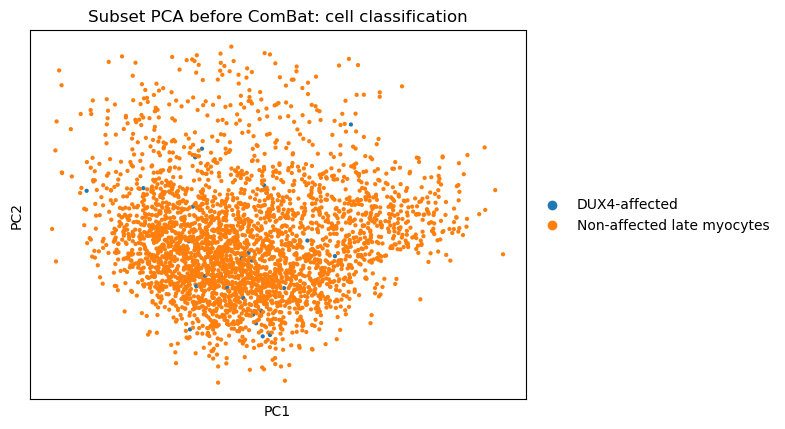

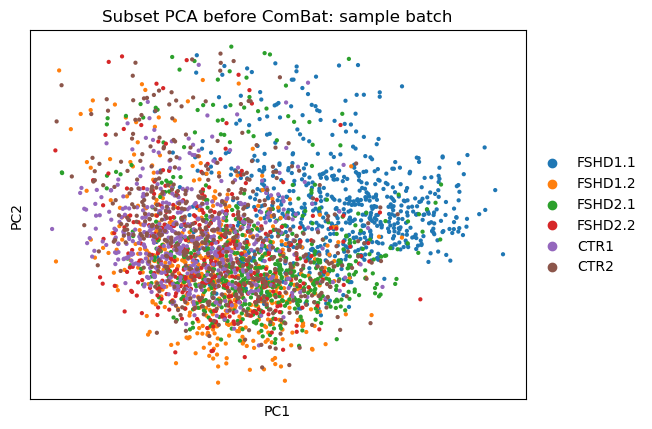

In [22]:
# select HVG （only DUX4 affected and non-affected cells)

# Subset DUX4-affected cells and non-affected late myocytes
adata_subset_before = adata_norm[
    adata_norm.obs["cell_classification"].isin([
        "DUX4-affected",
        "Non-affected late myocytes"
    ])
].copy()

# Use log-normalized data for HVG selection
adata_subset_before.X = adata_subset_before.layers["lognorm"].copy()

# Select highly variable genes on log-normalized data
sc.pp.highly_variable_genes(
    adata_subset_before,
    n_top_genes=2000,
    flavor="seurat"
)

# Save the same HVGs for before and after ComBat PCA
hvg_genes_subset = adata_subset_before.var_names[
    adata_subset_before.var["highly_variable"]
]
  
# PCA before ComBat correction
adata_pca_subset_before = adata_subset_before[:, hvg_genes_subset].copy()

# Use log-normalized data
adata_pca_subset_before.X = adata_pca_subset_before.layers["lognorm"].copy()

# Scale and run PCA
sc.pp.scale(adata_pca_subset_before, max_value=10)
sc.tl.pca(adata_pca_subset_before, svd_solver="arpack")

# PCA colored by cell classification
sc.pl.pca(
    adata_pca_subset_before,
    color="cell_classification",
    title="Subset PCA before ComBat: cell classification"
)

# PCA colored by sample
sc.pl.pca(
    adata_pca_subset_before,
    color="sample_batch",
    title="Subset PCA before ComBat: sample batch"
)

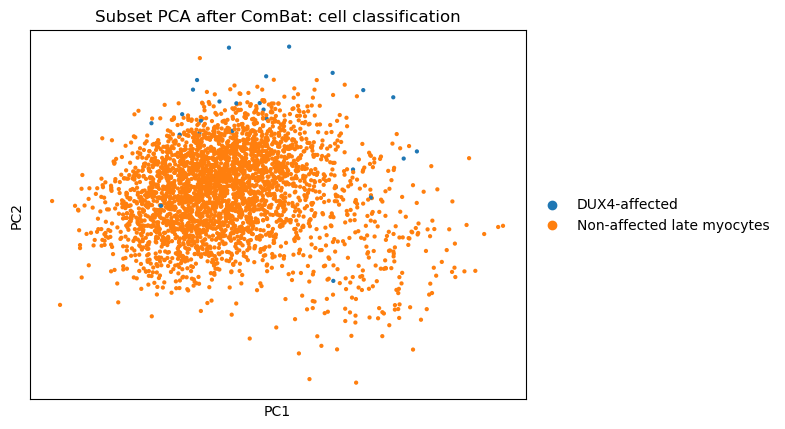

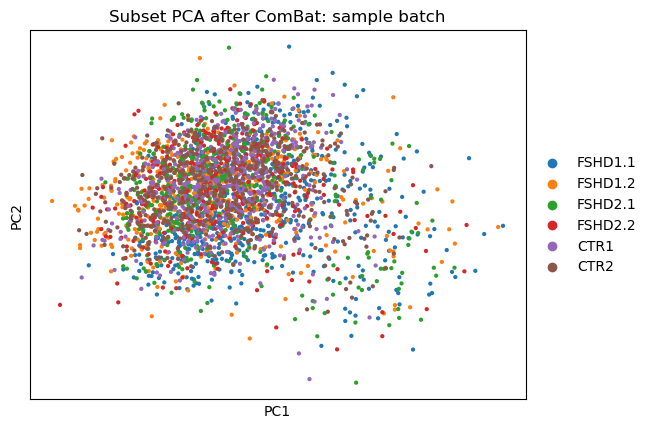

In [23]:
# PCA after combat(using same HVG as before)

# Subset the ComBat-corrected object
adata_pca_subset_after = adata_combat[
    adata_combat.obs["cell_classification"].isin([
        "DUX4-affected",
        "Non-affected late myocytes"
    ])
].copy()

# Use the same HVGs as before
adata_pca_subset_after = adata_pca_subset_after[:, hvg_genes_subset].copy()

# Use ComBat-corrected data
adata_pca_subset_after.X = adata_pca_subset_after.layers["combat"].copy()

# Scale and run PCA
sc.pp.scale(adata_pca_subset_after, max_value=10)
sc.tl.pca(adata_pca_subset_after, svd_solver="arpack")

# PCA colored by cell classification
sc.pl.pca(
    adata_pca_subset_after,
    color="cell_classification",
    title="Subset PCA after ComBat: cell classification"
)

# PCA colored by sample
sc.pl.pca(
    adata_pca_subset_after,
    color="sample_batch",
    title="Subset PCA after ComBat: sample batch"
)

d:\anaconda\envs\Phelma1\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


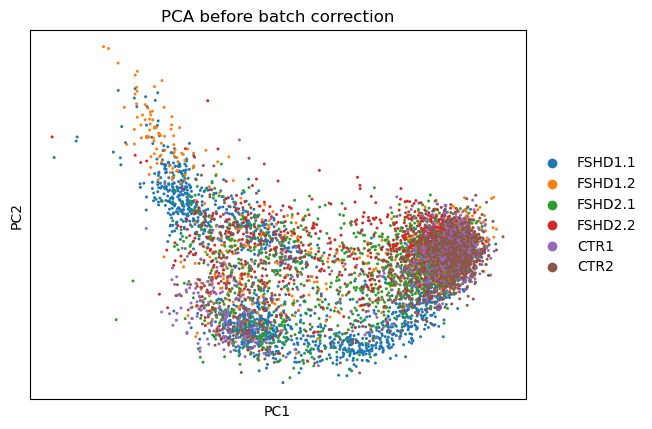

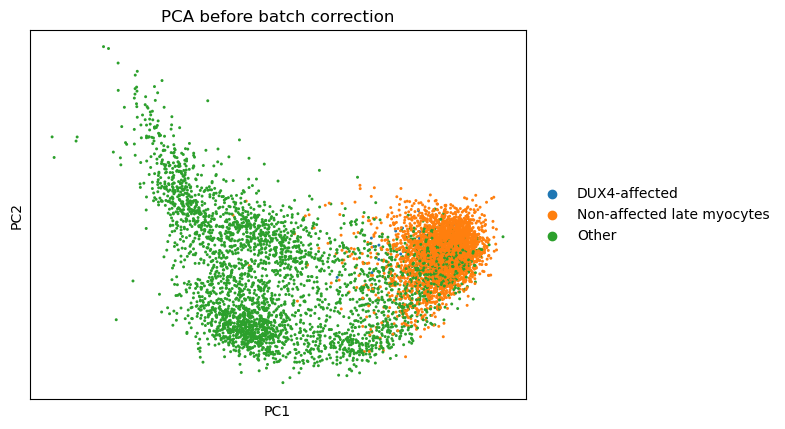

In [24]:
# PCA before batch correction (other cells included)
adata_pca_before = adata_combat.copy()

# Use log-normalized data
adata_pca_before.X = adata_pca_before.layers["lognorm"].copy()

# Select highly variable genes
sc.pp.highly_variable_genes(
    adata_pca_before,
    n_top_genes=2000,
    flavor="seurat"
)

# Keep only highly variable genes
adata_pca_before = adata_pca_before[:, adata_pca_before.var["highly_variable"]].copy()

# Scale data before PCA
sc.pp.scale(
    adata_pca_before,
    max_value=10
)

# Run PCA
sc.tl.pca(
    adata_pca_before,
    svd_solver="arpack"
)

# Plot PCA colored by sample
sc.pl.pca(
    adata_pca_before,
    color="sample_batch",
    title="PCA before batch correction"
)

# Plot PCA colored by cell classification
sc.pl.pca(
    adata_pca_before,
    color="cell_classification",
    title="PCA before batch correction"
)

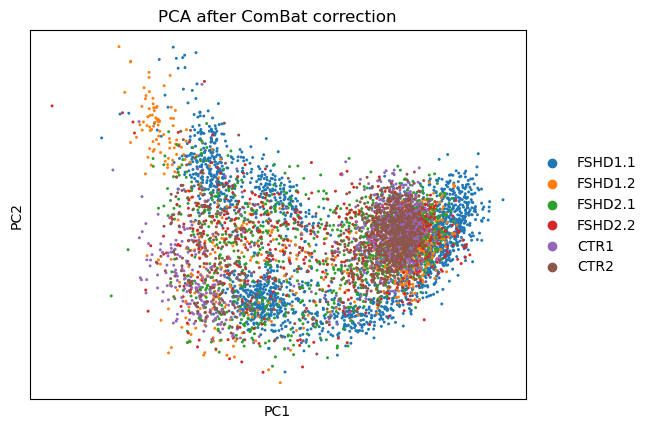

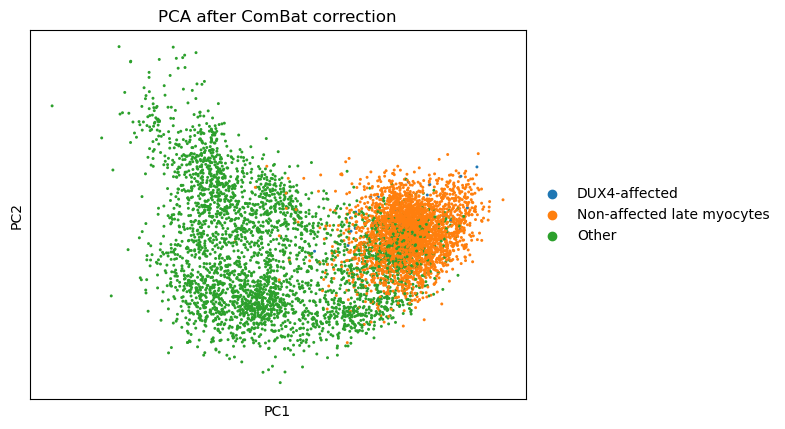

In [25]:
# PCA after ComBat correction(other cells included)
adata_pca_after = adata_combat.copy()

# Use ComBat-corrected data
adata_pca_after.X = adata_pca_after.layers["combat"].copy()

# Use the same highly variable genes as before
hvg_genes = adata_pca_before.var_names

adata_pca_after = adata_pca_after[:, hvg_genes].copy()

# Scale data before PCA
sc.pp.scale(
    adata_pca_after,
    max_value=10
)

# Run PCA
sc.tl.pca(
    adata_pca_after,
    svd_solver="arpack"
)

# Plot PCA colored by sample
sc.pl.pca(
    adata_pca_after,
    color="sample_batch",
    title="PCA after ComBat correction"
)

# Plot PCA colored by cell classification
sc.pl.pca(
    adata_pca_after,
    color="cell_classification",
    title="PCA after ComBat correction"
)

In [26]:

# Use batch effect removed data for differential expression
adata_de = adata_combat.copy()

# Use ComBat-corrected data
adata_de.X = adata_de.layers["combat"].copy()

print(adata_de.layers.keys())

KeysView(Layers with keys: counts, lognorm, combat)


In [27]:
# differential analysis

# Define FSHD samples
fshd_samples = ["FSHD1.1", "FSHD1.2", "FSHD2.1", "FSHD2.2"]

def run_de_for_sample(adata, sample_name):
    sub = adata[
        (adata.obs["sample_batch"] == sample_name) &
        (adata.obs["cell_classification"].isin([
            "DUX4-affected",
            "Non-affected late myocytes"
        ]))
    ].copy()
    
    # Remove unused categories
    sub.obs["cell_classification"] = sub.obs["cell_classification"].astype("category")
    sub.obs["cell_classification"] = sub.obs["cell_classification"].cat.remove_unused_categories()
    
    # Count cells in each group
    group_counts = sub.obs["cell_classification"].value_counts()
    
    print("\nSample:", sample_name)
    print(group_counts)
    
    
    # Check minimum cell number
    if group_counts["DUX4-affected"] < 2:
        print("Skipped: DUX4-affected group has fewer than 2 cells.")
        return None
    
    if group_counts["Non-affected late myocytes"] < 2:
        print("Skipped: reference group has fewer than 2 cells.")
        return None
    
    # Run Wilcoxon differential expression analysis
    sc.tl.rank_genes_groups(
        sub,
        groupby="cell_classification",
        groups=["DUX4-affected"],
        reference="Non-affected late myocytes",
        method="wilcoxon",
        corr_method="benjamini-hochberg",
        use_raw=False
    )
    
    # Convert result to dataframe
    de_df = sc.get.rank_genes_groups_df(
        sub,
        group="DUX4-affected"
    )
    
    de_df = de_df.rename(columns={"names": "gene_id"})
    de_df["sample"] = sample_name
    
    return de_df


de_results = []

for sample in fshd_samples:
    result = run_de_for_sample(adata_de, sample)
    if result is not None:
        de_results.append(result)

de_per_sample = pd.concat(de_results, ignore_index=True)



Sample: FSHD1.1
cell_classification
Non-affected late myocytes    711
DUX4-affected                  12
Name: count, dtype: int64


d:\anaconda\envs\Phelma1\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(



Sample: FSHD1.2
cell_classification
Non-affected late myocytes    518
DUX4-affected                   2
Name: count, dtype: int64


d:\anaconda\envs\Phelma1\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(



Sample: FSHD2.1
cell_classification
Non-affected late myocytes    575
DUX4-affected                  12
Name: count, dtype: int64


d:\anaconda\envs\Phelma1\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(



Sample: FSHD2.2
cell_classification
Non-affected late myocytes    358
DUX4-affected                   2
Name: count, dtype: int64


d:\anaconda\envs\Phelma1\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


In [28]:
for sample in fshd_samples:
    sub = de_per_sample[de_per_sample["sample"] == sample]
    print(sample)
    print("raw p < 0.05:", (sub["pvals"] < 0.05).sum())
    print("adj p < 0.05:", (sub["pvals_adj"] < 0.05).sum())

FSHD1.1
raw p < 0.05: 662
adj p < 0.05: 11
FSHD1.2
raw p < 0.05: 210
adj p < 0.05: 0
FSHD2.1
raw p < 0.05: 710
adj p < 0.05: 59
FSHD2.2
raw p < 0.05: 350
adj p < 0.05: 0


In [29]:
#Wilcoxon Rank Sum Test; BH FDR-corrected P-value < 0.05
# Keep significant differentially expressed genes

de_per_sample_sig = de_per_sample[
    (de_per_sample["pvals_adj"] < 0.05) &
    (de_per_sample["logfoldchanges"].abs() > 1)
].copy()





In [30]:
# Create significant gene sets for each sample
sig_gene_sets = {}

for sample in fshd_samples:
    genes = set(
        de_per_sample_sig.loc[
            de_per_sample_sig["sample"] == sample,
            "gene_id"
        ]
    )
    sig_gene_sets[sample] = genes

# Check number of significant genes per sample
for sample, genes in sig_gene_sets.items():
    print(sample, len(genes))

FSHD1.1 11
FSHD1.2 0
FSHD2.1 51
FSHD2.2 0


In [31]:
# Genes significant in FSHD1 samples but not in FSHD2 samples
fshd1_specific = (
    sig_gene_sets["FSHD1.1"] |
    sig_gene_sets["FSHD1.2"]
) - (
    sig_gene_sets["FSHD2.1"] |
    sig_gene_sets["FSHD2.2"]
)

print("FSHD1-specific genes:", len(fshd1_specific))

FSHD1-specific genes: 6


In [32]:
# Genes significant in FSHD2 samples but not in FSHD1 samples
fshd2_specific = (
    sig_gene_sets["FSHD2.1"] |
    sig_gene_sets["FSHD2.2"]
) - (
    sig_gene_sets["FSHD1.1"] |
    sig_gene_sets["FSHD1.2"]
)

print("FSHD2-specific genes:", len(fshd2_specific))

FSHD2-specific genes: 46


In [33]:

# Load gene annotation table
annotation_path = r"C:\Users\Tanya\Desktop\RNA sequencing\gencode.v49.basic.annotation.gff3"

# GFF3 standard column names
gff_cols = [
    "seqid", "source", "type", "start", "end",
    "score", "strand", "phase", "attributes"
]

# Read GFF3 file and skip comment lines
gff = pd.read_csv(
    annotation_path,
    sep="\t",
    comment="#",
    header=None,
    names=gff_cols,
    low_memory=False
)

# Keep only gene-level annotation
genes = gff[gff["type"] == "gene"].copy()

# Extract Ensembl gene ID and gene symbol
genes["gene_id"] = genes["attributes"].str.extract(r"(?:^|;)gene_id=([^;]+)")
genes["gene_name"] = genes["attributes"].str.extract(r"(?:^|;)gene_name=([^;]+)")

# Clean Ensembl ID: remove version number, e.g. ENSG00000106853.18 -> ENSG00000106853
genes["gene_id_clean"] = (
    genes["gene_id"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)
)

# Build annotation table
annotation = (
    genes[["gene_id_clean", "gene_name"]]
    .dropna()
    .drop_duplicates()
)

# Create mapping dictionary: clean Ensembl ID -> gene symbol
id_to_symbol = dict(zip(annotation["gene_id_clean"], annotation["gene_name"]))

# Convert a gene set to a dataframe and add gene symbols
def annotate_gene_set(gene_set, id_to_symbol, gene_set_name):
    # Convert set to dataframe
    df = pd.DataFrame({
        "ensembl_id": sorted(list(gene_set))
    })
    
    # Clean Ensembl ID in the gene set
    df["ensembl_id_clean"] = (
        df["ensembl_id"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.\d+$", "", regex=True)
    )
    
    # Map Ensembl ID to gene symbol
    df["gene_symbol"] = df["ensembl_id_clean"].map(id_to_symbol)
    
    # Add gene set name
    df.insert(0, "gene_set", gene_set_name)
    
    return df




In [34]:
# Annotate FSHD1-specific and FSHD2-specific gene sets
fshd1_specific_df = annotate_gene_set(
    fshd1_specific,
    id_to_symbol,
    "FSHD1-specific"
)

fshd2_specific_df = annotate_gene_set(
    fshd2_specific,
    id_to_symbol,
    "FSHD2-specific"
)

print(fshd1_specific_df)
print(fshd2_specific_df)

         gene_set       ensembl_id ensembl_id_clean gene_symbol
0  FSHD1-specific  ENSG00000107745  ENSG00000107745       MICU1
1  FSHD1-specific  ENSG00000119986  ENSG00000119986       AVPI1
2  FSHD1-specific  ENSG00000138079  ENSG00000138079      SLC3A1
3  FSHD1-specific  ENSG00000158186  ENSG00000158186        MRAS
4  FSHD1-specific  ENSG00000180532  ENSG00000180532      ZSCAN4
5  FSHD1-specific  ENSG00000251258  ENSG00000251258      RFPL4B
          gene_set       ensembl_id ensembl_id_clean gene_symbol
0   FSHD2-specific  ENSG00000059804  ENSG00000059804      SLC2A3
1   FSHD2-specific  ENSG00000081189  ENSG00000081189       MEF2C
2   FSHD2-specific  ENSG00000100142  ENSG00000100142      POLR2F
3   FSHD2-specific  ENSG00000100811  ENSG00000100811         YY1
4   FSHD2-specific  ENSG00000108106  ENSG00000108106       UBE2S
5   FSHD2-specific  ENSG00000109063  ENSG00000109063        MYH3
6   FSHD2-specific  ENSG00000110801  ENSG00000110801       PSMD9
7   FSHD2-specific  ENSG00000112

In [35]:
# Save annotated gene sets
fshd1_specific_df.to_csv(
    "FSHD1_specific_reconstructed_with_gene_symbols.csv",
    index=False
)

fshd2_specific_df.to_csv(
    "FSHD2_specific_reconstructed_with_gene_symbols.csv",
    index=False
)

In [36]:
for min_cells in [0,1, 3, 5, 10]:
    temp = adata_norm.copy()
    temp.X = temp.layers["lognorm"].copy()
    sc.pp.filter_genes(temp, min_cells=min_cells)
    
    kept_genes = set(temp.var["ensembl_id"])
    dux4_kept = set(dux4_genes_present) & kept_genes
    
    print(f"min_cells = {min_cells}")
    print("Genes kept:", temp.n_vars)
    print("DUX4-67 genes kept:", len(dux4_kept), "/", len(dux4_genes_present))

min_cells = 0
Genes kept: 33694
DUX4-67 genes kept: 43 / 43
min_cells = 1
Genes kept: 21390
DUX4-67 genes kept: 36 / 43
min_cells = 3
Genes kept: 18478
DUX4-67 genes kept: 31 / 43
min_cells = 5
Genes kept: 17330
DUX4-67 genes kept: 30 / 43
min_cells = 10
Genes kept: 15804
DUX4-67 genes kept: 23 / 43


In [ ]:
adata_de.X = adata_de.layers["combat"].copy()

# transfer gene_id to gene_sympol

# Add gene symbols to DE result
de_per_sample["gene_id_clean"] = (
    de_per_sample["gene_id"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)
)

de_per_sample["gene_symbol"] = de_per_sample["gene_id_clean"].map(id_to_symbol)

# Use gene_id as backup if gene symbol is missing
de_per_sample["gene_label"] = de_per_sample["gene_symbol"].fillna(
    de_per_sample["gene_id"]
)

# Add gene symbols to adata.var
adata_de.var["ensembl_id_clean"] = (
    adata_de.var["ensembl_id"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.\d+$", "", regex=True)
)

adata_de.var["gene_symbol"] = adata_de.var["ensembl_id_clean"].map(id_to_symbol)
adata_de.var["gene_label"] = adata_de.var["gene_symbol"].fillna(
    adata_de.var["ensembl_id"]
)

In [57]:
# volcano plot based on per sample differential analysis

# function for volcano plot
def plot_volcano(
    de_df,
    title,
    gene_col="gene_symbol",
    logfc_col="logfoldchanges",
    padj_col="pvals_adj",
    padj_cutoff=0.05,
    logfc_cutoff=1,
    label_top=10     # label the top 10 expressed genes
):
    df = de_df.copy()
    
    # Remove missing or infinite values
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=[logfc_col, padj_col])
    
    # Avoid -log10(0)
    df[padj_col] = df[padj_col].replace(0, 1e-300)
    
    # Calculate -log10 adjusted p-value
    df["minus_log10_padj"] = -np.log10(df[padj_col])
    
    # Define significant genes
    if logfc_cutoff is None:
        df["significant"] = df[padj_col] < padj_cutoff
    else:
        df["significant"] = (
            (df[padj_col] < padj_cutoff) &
            (df[logfc_col].abs() > logfc_cutoff)
        )
    
    plt.figure(figsize=(7, 5))
    
    # Non-significant genes
    plt.scatter(
        df.loc[~df["significant"], logfc_col],
        df.loc[~df["significant"], "minus_log10_padj"],
        s=8,
        alpha=0.4,
        label="Not significant"
    )
    
    # Significant genes
    plt.scatter(
        df.loc[df["significant"], logfc_col],
        df.loc[df["significant"], "minus_log10_padj"],
        s=12,
        alpha=0.8,
        label="Significant"
    )
    
    # Cutoff lines
    plt.axhline(-np.log10(padj_cutoff), linestyle="--", linewidth=1)
    
    if logfc_cutoff is not None:
        plt.axvline(logfc_cutoff, linestyle="--", linewidth=1)
        plt.axvline(-logfc_cutoff, linestyle="--", linewidth=1)
    
    # Label top significant genes
    top_genes = df[df["significant"]].sort_values(padj_col).head(label_top)
    
    for _, row in top_genes.iterrows():
        plt.text(
            row[logfc_col],
            row["minus_log10_padj"],
            str(row[gene_col]),
            fontsize=8)
    
    
    plt.xlabel("log2 fold change")
    plt.ylabel("-log10 adjusted p-value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

FSHD1.1 DE genes: 21390
Significant genes: 11


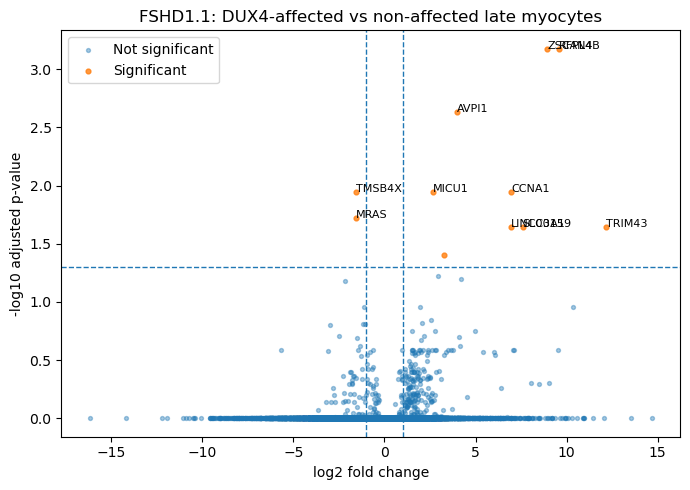

FSHD2.1 DE genes: 21390
Significant genes: 51


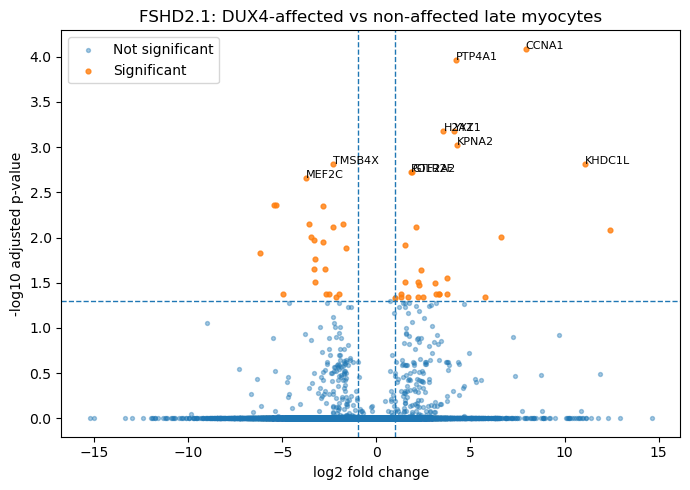

In [58]:
# volcano plots for each sample
fshd_samples = ["FSHD1.1", "FSHD2.1"]

for sample in fshd_samples:
    sub = de_per_sample[
        de_per_sample["sample"] == sample
    ].copy()
    
    # number of significant genes
    print(sample, "DE genes:", sub.shape[0])
    print("Significant genes:", ((sub["pvals_adj"] < 0.05) & (sub["logfoldchanges"].abs() > 1)).sum())
    
    if sub.shape[0] == 0:
        print(sample, "has no DE result, skipped.")
        continue
    
    #plot
    plot_volcano(
        sub,
        title=f"{sample}: DUX4-affected vs non-affected late myocytes",
        gene_col="gene_symbol",
        padj_cutoff=0.05,
        logfc_cutoff=1)

In [40]:
top_gene_summary = []
top_genes = []
top_genes_by_sample = {}

for sample in ["FSHD1.1", "FSHD1.2", "FSHD2.1", "FSHD2.2"]:
    sub = de_per_sample[
        (de_per_sample["sample"] == sample) &
        (de_per_sample["pvals_adj"] < 0.05) &
        (de_per_sample["logfoldchanges"] > 1)
    ].copy()
    
    sub = sub.sort_values("pvals_adj")
    
    # Keep top 10 genes
    selected = sub["gene_id_clean"].head(10).tolist()
    # Remove duplicated genes
    top_genes = list(dict.fromkeys(top_genes))

    top_genes_by_sample[sample] = selected
    top_genes.extend(selected)
    
    top_gene_summary.append({
        "sample": sample,
        "top_genes_selected": len(selected)
    })

top_gene_summary_df = pd.DataFrame(top_gene_summary)

print("Number of genes for heatmap:", len(top_genes))
print(top_gene_summary_df)

Number of genes for heatmap: 17
    sample  top_genes_selected
0  FSHD1.1                   9
1  FSHD1.2                   0
2  FSHD2.1                  10
3  FSHD2.2                   0


In [41]:
# Build mapping: clean Ensembl ID -> adata var_name
id_to_varname = dict(zip(
    adata_de.var["ensembl_id_clean"],
    adata_de.var_names
))

# Convert selected gene IDs to var_names used by adata
top_var_names = [
    id_to_varname[g]
    for g in top_genes
    if g in id_to_varname
]

print("Genes found in adata:", len(top_var_names))


Genes found in adata: 17


In [ ]:
# Keep FSHD samples and two cell classes
adata_heat = adata_de[
    (adata_de.obs["sample_batch"].isin([
        "FSHD1.1", "FSHD1.2", "FSHD2.1", "FSHD2.2"
    ])) &
    (adata_de.obs["cell_classification"].isin([
        "DUX4-affected",
        "Non-affected late myocytes"
    ]))
].copy()

# Use combat-corrected data
adata_heat.X = adata_heat.layers["combat"].copy()

# Create sample + cell class group
adata_heat.obs["sample_cell_class"] = (
    adata_heat.obs["sample_batch"].astype(str)
    + " | "
    + adata_heat.obs["cell_classification"].astype(str)
)


In [51]:
# Create short sample labels
adata_heat.obs["sample_short"] = (
    adata_heat.obs["sample_batch"]
    .astype(str)
    .str.replace("FSHD", "", regex=False)
)

# Create short class labels
class_map = {
    "DUX4-affected": "A",
    "Non-affected late myocytes": "B"
}

adata_heat.obs["class_short"] = (
    adata_heat.obs["cell_classification"]
    .map(class_map)
)

# Create heatmap column labels
adata_heat.obs["heat_group"] = (
    adata_heat.obs["sample_short"].astype(str)
    + "-"
    + adata_heat.obs["class_short"].astype(str)
)

# Define column order
group_order = [
    "1.1-A", "1.1-B",
    "1.2-A", "1.2-B",
    "2.1-A", "2.1-B",
    "2.2-A", "2.2-B"
]

# Keep only groups that exist
group_order = [
    g for g in group_order
    if g in adata_heat.obs["heat_group"].unique()
]

adata_heat.obs["heat_group"] = pd.Categorical(
    adata_heat.obs["heat_group"],
    categories=group_order,
    ordered=True
)

print(adata_heat.obs["heat_group"].value_counts())

heat_group
1.1-B    711
2.1-B    575
1.2-B    518
2.2-B    358
2.1-A     12
1.1-A     12
1.2-A      2
2.2-A      2
Name: count, dtype: int64


In [52]:
# Extract log-normalized expression of selected genes
X = adata_heat[:, top_var_names].layers["combat"]

if sparse.issparse(X):
    X = X.toarray()

# Create expression dataframe
expr_df = pd.DataFrame(
    X,
    index=adata_heat.obs_names,
    columns=top_var_names
)

# Add group information
expr_df["heat_group"] = adata_heat.obs["heat_group"].values

# Calculate average expression per group
mean_expr = (
    expr_df
    .groupby("heat_group", observed=True)
    .mean()
    .T
)

# Reorder columns
mean_expr = mean_expr[group_order]


In [53]:
# Z-score scaling per gene
heat_data = mean_expr.sub(mean_expr.mean(axis=1), axis=0)
heat_data = heat_data.div(mean_expr.std(axis=1).replace(0, np.nan), axis=0)

# Replace NaN caused by zero standard deviation
heat_data = heat_data.fillna(0)

# Limit extreme values for clearer colors
heat_data = heat_data.clip(-1.5, 1.5)

In [54]:
# Add gene symbol labels
if "gene_symbol" not in adata_heat.var.columns:
    adata_heat.var["ensembl_id_clean"] = (
        adata_heat.var_names
        .astype(str)
        .str.replace('"', '', regex=False)
        .str.strip()
        .str.replace(r"\.\d+$", "", regex=True)
    )
    adata_heat.var["gene_symbol"] = (
        adata_heat.var["ensembl_id_clean"].map(id_to_symbol)
    )

# Create label map
gene_label_map = (
    adata_heat.var["gene_symbol"]
    .fillna(pd.Series(adata_heat.var_names, index=adata_heat.var_names))
    .to_dict()
)

# Replace ENSG index by gene symbols
gene_labels = [
    gene_label_map.get(g, g)
    for g in heat_data.index
]

heat_data.index = gene_labels

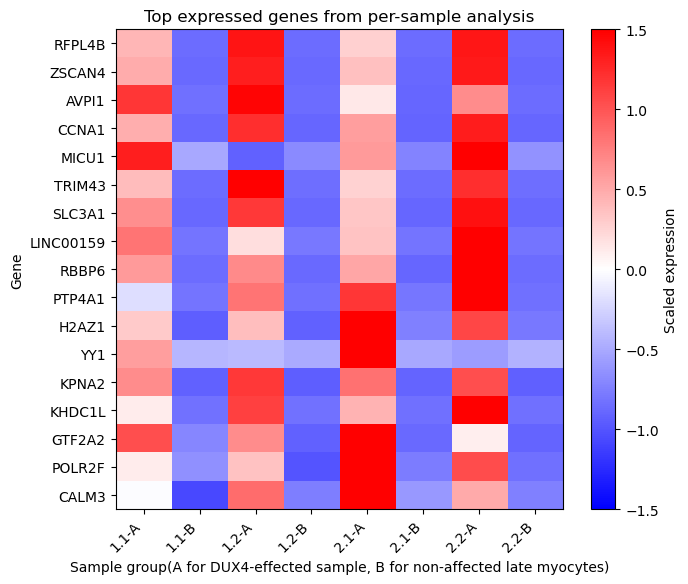

In [55]:
# Plot heatmap: genes as rows, samples/groups as columns
fig_height = max(5, 0.35 * heat_data.shape[0])
fig_width = max(7, 0.7 * heat_data.shape[1])

plt.figure(figsize=(fig_width, fig_height))

plt.imshow(
    heat_data.values,
    aspect="auto",
    cmap="bwr",
    vmin=-1.5,
    vmax=1.5
)

plt.colorbar(label="Scaled expression")

plt.xticks(
    ticks=np.arange(heat_data.shape[1]),
    labels=heat_data.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(heat_data.shape[0]),
    labels=heat_data.index
)

plt.xlabel("Sample group(A for DUX4-effected sample, B for non-affected late myocytes)")
plt.ylabel("Gene")
plt.title("Top expressed genes from per-sample analysis")

plt.tight_layout()
plt.show()

In [49]:
# Check all layers in AnnData
adata_de.layers.keys()

KeysView(Layers with keys: counts, lognorm, combat)